In [149]:
from sklearn.datasets import make_circles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [150]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [151]:
len(X), len(y)

(1000, 1000)

In [152]:
print(X[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [153]:
circles = pd.DataFrame({
    'X1': X[:, 0],
    'X2': X[:, 1],
    'label': y
})

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


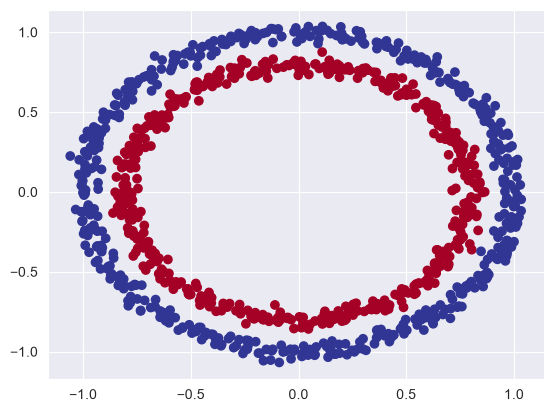

In [154]:
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu_r)

In [155]:
import torch
torch.__version__

'2.13.0+cu126'

In [156]:
X_copy = X.copy()
y_copy = y.copy()

X_torch = torch.from_numpy(X_copy).type(torch.float32)
y_torch = torch.from_numpy(y_copy).type(torch.float32)

In [157]:
X_torch[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [158]:
torch.manual_seed(42)

In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_torch, y_torch, test_size=0.2, random_state=42)

In [160]:
X_train[:5], y_train[:5], len(X_test), len(y_test)

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]),
 200,
 200)

In [161]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Our model will be:

1. subclasses nn.Module
2. create 2 nn.Linear()
3. activation function: Relu()
4. optimizer: Adam
5. cost function: BCELoss (Binary Cross Entropy Loss)


In [162]:
class CircleModelv0(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=5)
        self.fc2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, X):
        X = self.fc1(X)
        X = F.leaky_relu(X)
        X = self.fc2(X)
        return torch.sigmoid(X)

In [163]:
class CircleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=16)
        self.fc2 = nn.Linear(in_features=16, out_features=32)
        self.fc3 = nn.Linear(in_features=32, out_features=1)

    def forward(self, X):
        X = self.fc1(X)
        X = F.leaky_relu(X)
        X = self.fc2(X)
        X = F.leaky_relu(X)
        X = self.fc3(X)
        return torch.sigmoid(X)

In [164]:
model_0 = CircleModelv0().to(device)
model_0

CircleModelv0(
  (fc1): Linear(in_features=2, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=1, bias=True)
)

In [165]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [166]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.4753],
        [0.4800],
        [0.4524],
        [0.4823],
        [0.4758]], device='cuda:0')

In [167]:
torch.cuda.manual_seed(42)

In [168]:
def train_step(model: nn.Module, optimizer: optim.Optimizer, loss_function: nn.Module,
                X_train: torch.Tensor, y_train: torch.Tensor) -> float:
    model.train()
    y_pred = model(X_train).squeeze()
    loss = loss_function(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

In [169]:
def test_step(model: nn.Module, loss_function: nn.Module,
               X_test: torch.Tensor, y_test: torch.Tensor) -> float:
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).squeeze()
        loss = loss_function(y_pred, y_test)

    return loss.item()

In [170]:
def train_model(model: nn.Module, optimizer: optim.Optimizer, loss_function: nn.Module,
                 X_train: torch.Tensor, y_train: torch.Tensor,
                 X_test: torch.Tensor, y_test: torch.Tensor, epochs: int = 500,  patience=5, delta=0.0001):
    epoch_list = []
    train_loss_list = []
    test_loss_list = []

    best_val_loss = float("inf")
    no_improvement_count = 0

    for epoch in range(epochs + 1):
        train_loss = train_step(model, optimizer, loss_function, X_train, y_train)

        if epoch % 100 == 0:
            test_loss = test_step(model, loss_function, X_test, y_test)

            epoch_list.append(epoch)
            train_loss_list.append(train_loss)
            test_loss_list.append(test_loss)
            print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

            if test_loss < best_val_loss - delta:
                best_val_loss = test_loss
                no_improvement_count = 0
            else:
                no_improvement_count += 1

            if no_improvement_count >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    return model, epoch_list, train_loss_list, test_loss_list

In [171]:
optimizer = optim.Adam(model_0.parameters(), lr=0.01)
loss_function = nn.BCELoss()
epochs = 500

epoch_list = []
train_loss = []
test_loss = []

model, epoch_list, train_loss, test_loss = train_model(model_0, optimizer, loss_function, X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device), epochs)

Epoch: 0 | Train Loss: 0.6975 | Test Loss: 0.6976
Epoch: 100 | Train Loss: 0.5855 | Test Loss: 0.5954
Epoch: 200 | Train Loss: 0.3625 | Test Loss: 0.3804
Epoch: 300 | Train Loss: 0.2065 | Test Loss: 0.2363
Epoch: 400 | Train Loss: 0.1392 | Test Loss: 0.1723
Epoch: 500 | Train Loss: 0.1061 | Test Loss: 0.1405


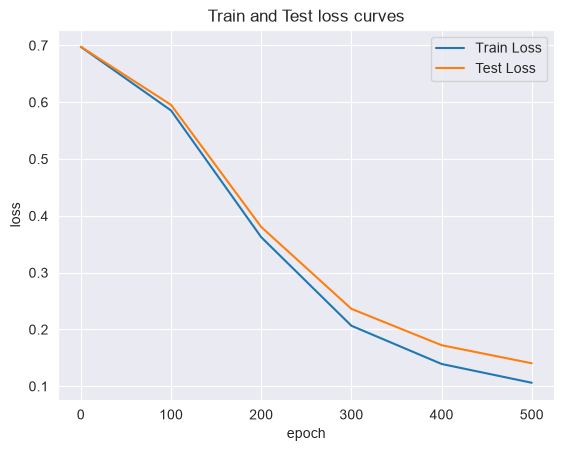

In [172]:
plt.plot(epoch_list, train_loss, label='Train Loss')
plt.plot(epoch_list, test_loss, label='Test Loss')
plt.title("Train and Test loss curves")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

In [173]:
with torch.inference_mode():
    y_pred = model(X_test.to(device)).squeeze()
    y_pred = torch.round(y_pred)

    report = classification_report(
        y_test.cpu(),
        y_pred.cpu()
    )

    print(report)

              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96       100
         1.0       0.96      0.97      0.97       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



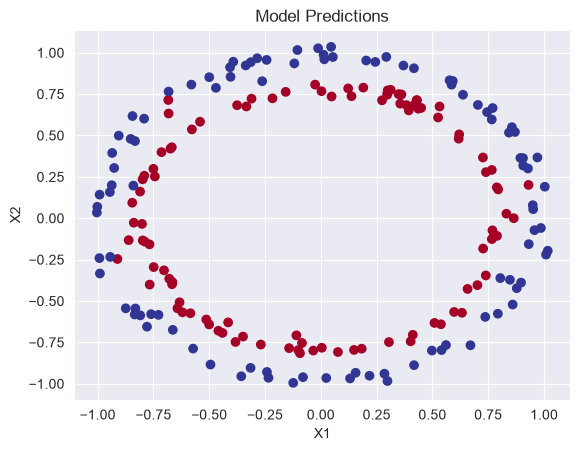

In [174]:
with torch.inference_mode():
    y_pred = model(X_test.to(device)).squeeze()
    y_pred = torch.round(y_pred)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred.cpu(),
    cmap=plt.cm.RdYlBu_r
)

plt.title("Model Predictions")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

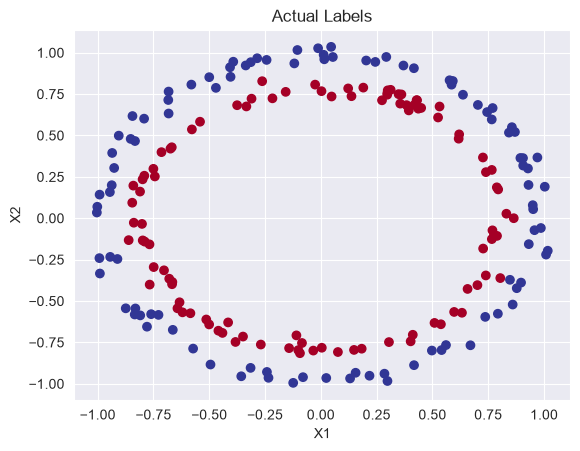

In [175]:
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap=plt.cm.RdYlBu_r
)

plt.title("Actual Labels")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [176]:
model_1 = CircleModelv1().to(device)

In [177]:
optimizer2 = optim.Adam(model_1.parameters(), lr=0.01)
loss_function2 = nn.BCELoss()
epochs = 500

epoch_list2 = []
train_loss2 = []
test_loss2 = []

model2, epoch_list2, train_loss2, test_loss2 = train_model(model_1, optimizer2, loss_function2, X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device), epochs)

Epoch: 0 | Train Loss: 0.6974 | Test Loss: 0.6913
Epoch: 100 | Train Loss: 0.0082 | Test Loss: 0.0189
Epoch: 200 | Train Loss: 0.0018 | Test Loss: 0.0065
Epoch: 300 | Train Loss: 0.0009 | Test Loss: 0.0043
Epoch: 400 | Train Loss: 0.0005 | Test Loss: 0.0032
Epoch: 500 | Train Loss: 0.0003 | Test Loss: 0.0025


In [178]:
with torch.inference_mode():
    y_pred = model2(X_test.to(device)).squeeze()
    y_pred = torch.round(y_pred)

    report = classification_report(
        y_test.cpu(),
        y_pred.cpu()
    )

    print(report)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       100
         1.0       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



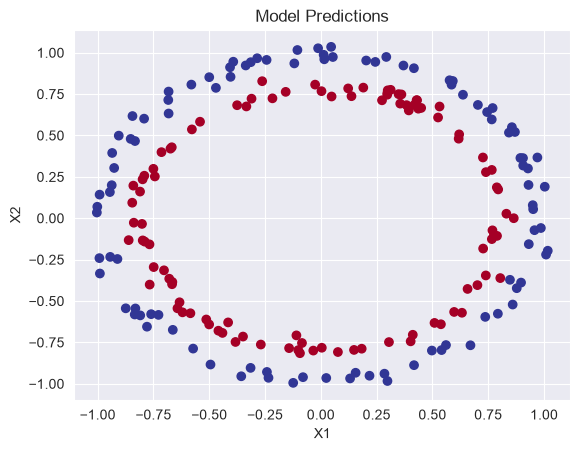

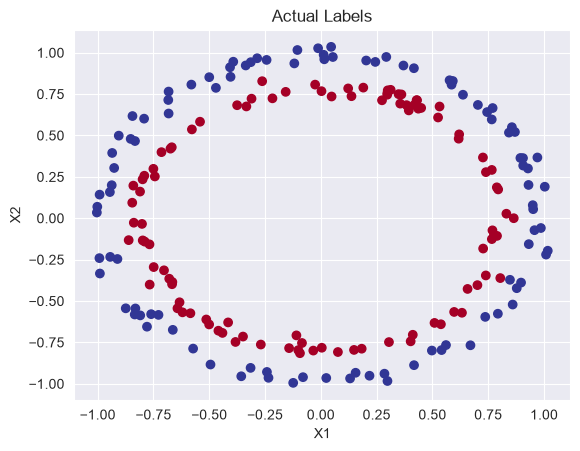

In [179]:
with torch.inference_mode():
    y_pred = model2(X_test.to(device)).squeeze()
    y_pred = torch.round(y_pred)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred.cpu(),
    cmap=plt.cm.RdYlBu_r
)

plt.title("Model Predictions")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap=plt.cm.RdYlBu_r
)

plt.title("Actual Labels")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

### Multiclass Classification (Softmax)

In [180]:
from sklearn.datasets import make_blobs

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1_000_000, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED)

In [181]:
X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.uint8)

In [182]:
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

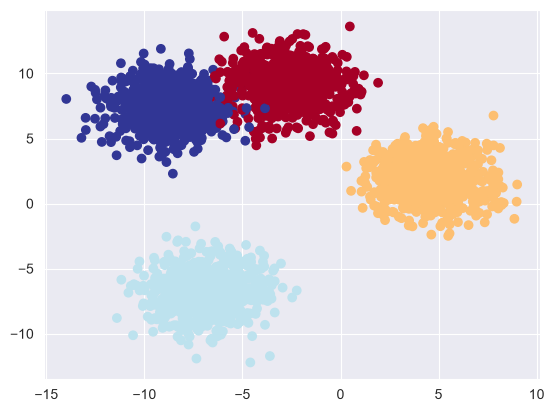

In [183]:
plt.scatter(X_blob[:3000, 0], X_blob[:3000, 1], c=y_blob[:3000], cmap=plt.cm.RdYlBu)

In [184]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=128):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units * 2)
        self.fc3 = nn.Linear(hidden_units * 2, hidden_units)
        self.fc4 = nn.Linear(hidden_units, output_features)
        self.relu = nn.ReLU()

    def forward(self, X):
        z1 = self.fc1(X)
        a1 = self.relu(z1)
        z2 = self.fc2(a1)
        a2 = self.relu(z2)
        z3 = self.fc3(a2)
        a3 = self.relu(z3)
        yhat = self.fc4(a3)

        return yhat

In [185]:
patience = 3
delta = 0.00001
best_val_loss = float("inf")
no_improvement_count = 0

In [187]:
model_b = BlobModel(
    input_features=2,
    output_features=4
).to(device)

optimizer_b = torch.optim.Adam(model_b.parameters(), lr=0.001)
loss_function_b = nn.CrossEntropyLoss()

model, epoch_list, train_loss, test_loss = train_model(
    model_b,
    optimizer_b,
    loss_function_b,
    X_b_train.to(device),
    y_b_train.to(device),
    X_b_test.to(device),
    y_b_test.to(device),
    epochs=3000,
    patience=patience,
    delta=delta
)

Epoch: 0 | Train Loss: 1.5006 | Test Loss: 1.1196
Epoch: 100 | Train Loss: 0.0237 | Test Loss: 0.0239
Epoch: 200 | Train Loss: 0.0202 | Test Loss: 0.0204
Epoch: 300 | Train Loss: 0.0202 | Test Loss: 0.0204
Epoch: 400 | Train Loss: 0.0202 | Test Loss: 0.0204
Epoch: 500 | Train Loss: 0.0202 | Test Loss: 0.0204
Epoch: 600 | Train Loss: 0.0202 | Test Loss: 0.0204
Early stopping at epoch 600


In [188]:
with torch.inference_mode():
    y_logits = model_b(X_b_test.to(device))

y_preds = F.softmax(y_logits, dim=1)

y_logits[:5], y_preds[:5]

(tensor([[-13.7125,  -1.5898,  16.9210,  -4.8610],
         [-15.7287,  -1.3155,  19.5556,  -6.2838],
         [  8.1170,  -2.3055,  -5.8330,   0.6070],
         [ 10.8364,  -4.6960,  -7.8877,   2.4341],
         [-10.6385,  -1.0028,  13.1854,  -4.0445]], device='cuda:0'),
 tensor([[4.9663e-14, 9.1379e-09, 1.0000e+00, 3.4689e-10],
         [4.7449e-16, 8.6259e-10, 1.0000e+00, 5.9992e-12],
         [9.9942e-01, 2.9738e-05, 8.7366e-07, 5.4726e-04],
         [9.9978e-01, 1.7959e-07, 7.3818e-09, 2.2430e-04],
         [4.5022e-11, 6.8888e-07, 1.0000e+00, 3.2897e-08]], device='cuda:0'))

In [191]:
with torch.inference_mode():
    y_logits = model_b(X_b_test.to(device))
    y_preds = torch.argmax(y_logits, dim=1)

print(classification_report(
    y_b_test.cpu(),
    y_preds.cpu()
))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     49746
           1       1.00      1.00      1.00     49892
           2       1.00      1.00      1.00     50215
           3       0.99      0.98      0.99     50147

    accuracy                           0.99    200000
   macro avg       0.99      0.99      0.99    200000
weighted avg       0.99      0.99      0.99    200000



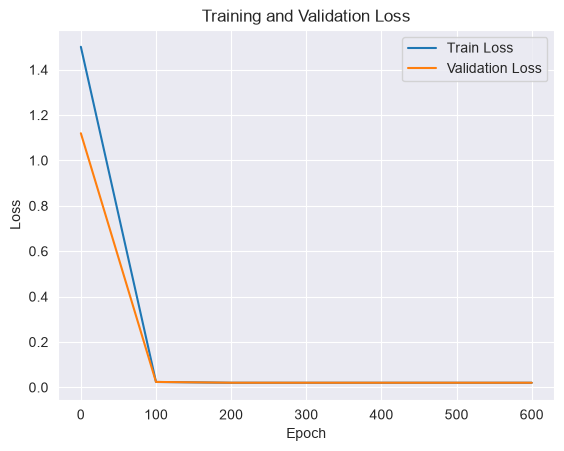

In [192]:
plt.plot(epoch_list, train_loss, label="Train Loss")
plt.plot(epoch_list, test_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

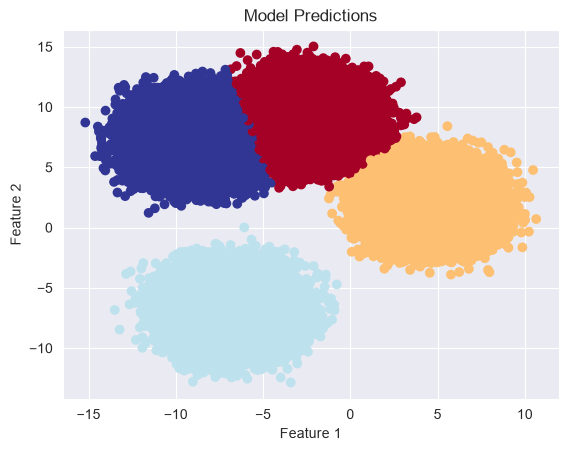

In [193]:
with torch.inference_mode():
    logits = model_b(X_b_test.to(device))
    y_preds = torch.argmax(logits, dim=1)

plt.scatter(
    X_b_test[:, 0],
    X_b_test[:, 1],
    c=y_preds.cpu(),
    cmap=plt.cm.RdYlBu
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Model Predictions")
plt.show()

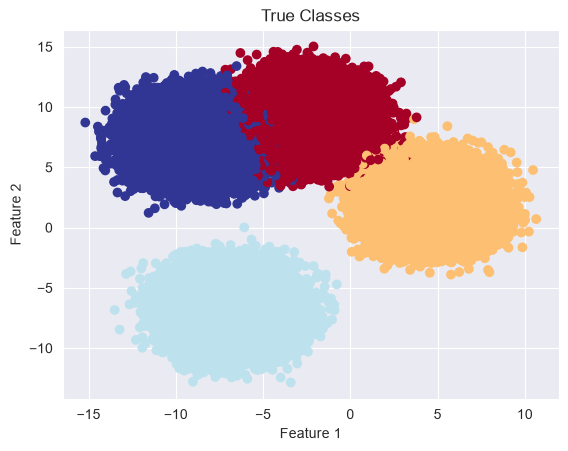

In [194]:
plt.scatter(
    X_b_test[:, 0],
    X_b_test[:, 1],
    c=y_b_test,
    cmap=plt.cm.RdYlBu
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("True Classes")
plt.show()